In [1]:
# data pre-processing
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# data mining
from sklearn.decomposition import PCA

# visualization
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings(action = 'ignore')

In [3]:

from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer


In [67]:

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [159]:
from scipy.stats import f_oneway

In [5]:
# Read file
station = pd.read_csv("station_ecology_master.csv")

station.head()

,station_id,station_name,district,address,latitude,longitude,installation_date,lcd_rack_count,qr_rack_count,operation_type,...,middle_age_ratio,age_entropy,destination_entropy,inflow_outflow_ratio,degree_centrality,closeness_centrality,foreigner_activity,foreigner_balance,foreigner_stability,foreigner_daily_mean
0,301,경복궁역 7번출구 앞,종로구,서울특별시 종로구 사직로 지하130 경복궁역 7번출구 앞,37.575794,126.971451,2015-10-07 12:03:46.000,0.0,20.0,QR,...,0.622050,1.571667,0.000000,0.000000,0.000000,0.000000,61.0,0.196078,0.420806,1.967742
1,302,경복궁역 4번출구 뒤,종로구,서울특별시 종로구 사직로 지하130 경복궁역 4번출구 뒤,37.575947,126.974060,2015-10-07 12:04:22.000,0.0,12.0,QR,...,0.573147,1.549042,4.140862,1.053792,0.099198,0.404017,377.0,0.984211,0.182805,4.010638
2,303,광화문역 1번출구 앞,종로구,서울특별시 종로구 세종대로 지하189 세종로공원,37.571770,126.974663,2015-10-07 00:00:00.000,0.0,8.0,QR,...,0.663649,1.574669,3.877326,0.992530,0.081692,0.380265,59.0,0.552632,0.358085,2.565217
3,305,종로구청 옆,종로구,서울특별시 종로구 세종로 84-1,37.572559,126.978333,2015-01-07 00:00:00.000,0.0,16.0,QR,...,0.693084,1.565585,0.000000,0.000000,0.000000,0.000000,66.0,1.062500,0.408887,1.650000
4,307,서울역사박물관 앞,종로구,서울특별시 종로구 새문안로 55 서울역사박물관 앞,37.570000,126.971100,2015-10-07 12:09:09.000,0.0,11.0,QR,...,0.646261,1.551401,3.634888,1.029791,0.113786,0.455242,38.0,1.235294,0.457997,1.809524


In [7]:

# Delete categorical column
station = station.drop(columns=[
    "latitude",
    "longitude",
    "district",
    "address",
    "operation_type",
    "station_type" ,
    "station_name",
    "station_id",
    "round_trip_ratio"

])



In [9]:
station.head()

,installation_date,lcd_rack_count,qr_rack_count,total_rack_count,qr_ratio,station_age_days,avg_trip_duration,avg_distance,sprout_bike_ratio,foreigner_ratio,...,middle_age_ratio,age_entropy,destination_entropy,inflow_outflow_ratio,degree_centrality,closeness_centrality,foreigner_activity,foreigner_balance,foreigner_stability,foreigner_daily_mean
0,2015-10-07 12:03:46.000,0.0,20.0,20.0,1.0,3883,15.625478,1.487048,0.091720,0.002548,...,0.622050,1.571667,0.000000,0.000000,0.000000,0.000000,61.0,0.196078,0.420806,1.967742
1,2015-10-07 12:04:22.000,0.0,12.0,12.0,1.0,3883,16.966642,1.635869,0.058738,0.001450,...,0.573147,1.549042,4.140862,1.053792,0.099198,0.404017,377.0,0.984211,0.182805,4.010638
2,2015-10-07 00:00:00.000,0.0,8.0,8.0,1.0,3884,15.733066,1.441492,0.042649,0.000000,...,0.663649,1.574669,3.877326,0.992530,0.081692,0.380265,59.0,0.552632,0.358085,2.565217
3,2015-01-07 00:00:00.000,0.0,16.0,16.0,1.0,4157,21.576068,2.109980,0.034188,0.000855,...,0.693084,1.565585,0.000000,0.000000,0.000000,0.000000,66.0,1.062500,0.408887,1.650000
4,2015-10-07 12:09:09.000,0.0,11.0,11.0,1.0,3883,20.488591,1.989540,0.064430,0.004027,...,0.646261,1.551401,3.634888,1.029791,0.113786,0.455242,38.0,1.235294,0.457997,1.809524


In [11]:
# installation_date manipulation

station["installation_date"] = pd.to_datetime(
    station["installation_date"],
    format="mixed",
    errors="coerce"
)

today = pd.Timestamp.today()

station["days_since_installation"] = (
    today - station["installation_date"]
).dt.days

station = station.drop(columns=["installation_date"])
station = station.drop(columns=["station_age_days"])



station_st = StandardScaler().fit_transform(station)
station_st = pd.DataFrame(station_st, columns = station.columns)

station_st.head(10)

,lcd_rack_count,qr_rack_count,total_rack_count,qr_ratio,avg_trip_duration,avg_distance,sprout_bike_ratio,foreigner_ratio,nonmember_ratio,rush_hour_ratio,...,age_entropy,destination_entropy,inflow_outflow_ratio,degree_centrality,closeness_centrality,foreigner_activity,foreigner_balance,foreigner_stability,foreigner_daily_mean,days_since_installation
0,-0.725532,1.710330,1.431339,0.802099,-0.636463,-0.823703,3.644069,0.598253,-0.448559,1.418933,...,-0.034152,-1.037079,-1.007519,-0.858814,-1.049441,0.585982,-0.554504,0.340592,0.748165,1.628064
1,-0.725532,0.636801,-0.016091,0.802099,-0.372703,-0.601586,2.050881,0.227837,0.197617,0.734087,...,-0.208180,1.193880,1.122737,1.375022,1.060438,5.414327,0.363761,-0.392630,2.895306,1.628064
2,-0.725532,0.100037,-0.739806,0.802099,-0.615305,-0.891697,1.273697,-0.261686,0.335789,0.786764,...,-0.011062,1.051896,0.998896,0.980815,0.936396,0.555423,-0.139078,0.147363,1.376128,1.628064
3,-0.725532,1.173566,0.707624,0.802099,0.533813,0.106032,0.864972,0.026798,-0.401481,0.332439,...,-0.080934,-1.037079,-1.007519,-0.858814,-1.049441,0.662380,0.454977,0.303871,0.414209,1.966317
4,-0.725532,0.502610,-0.197020,0.802099,0.319943,-0.073726,2.325802,1.097479,-0.150972,-0.285161,...,-0.190034,0.921278,1.074219,1.703527,1.327946,0.234552,0.656302,0.455167,0.581873,1.628064
5,-0.725532,3.186432,3.421556,0.802099,-0.876249,-1.003341,1.038377,-0.261686,-0.298003,0.900340,...,-0.962616,1.342322,0.831518,1.555699,1.017404,0.051197,-0.166132,1.009203,0.118262,1.628064
6,-0.725532,0.770992,0.164838,0.802099,-0.079559,0.038638,1.221310,-0.261686,-0.321966,1.427508,...,0.198360,1.063032,1.025472,1.506424,1.072344,-0.071040,0.382158,0.855641,0.399877,1.628064
7,-0.725532,0.368419,-0.377949,0.802099,1.226418,-0.179161,0.679774,2.015049,1.054333,-0.421116,...,-0.093451,-1.037079,-1.007519,-0.858814,-1.049441,2.006982,0.162842,-0.013668,1.095809,1.628064
8,-0.725532,0.100037,-0.739806,0.802099,0.482784,-0.459755,0.571488,-0.035765,0.354341,0.931315,...,-0.298995,0.884835,1.009572,0.208828,0.716920,0.585982,0.142281,0.152127,0.565681,1.628064
9,-0.725532,1.039374,0.526695,0.802099,-0.522356,-0.616307,1.327528,2.692589,-0.231458,0.864988,...,0.041401,0.877493,1.054062,0.570184,1.034283,2.129219,0.326007,-0.179922,1.340428,1.628064


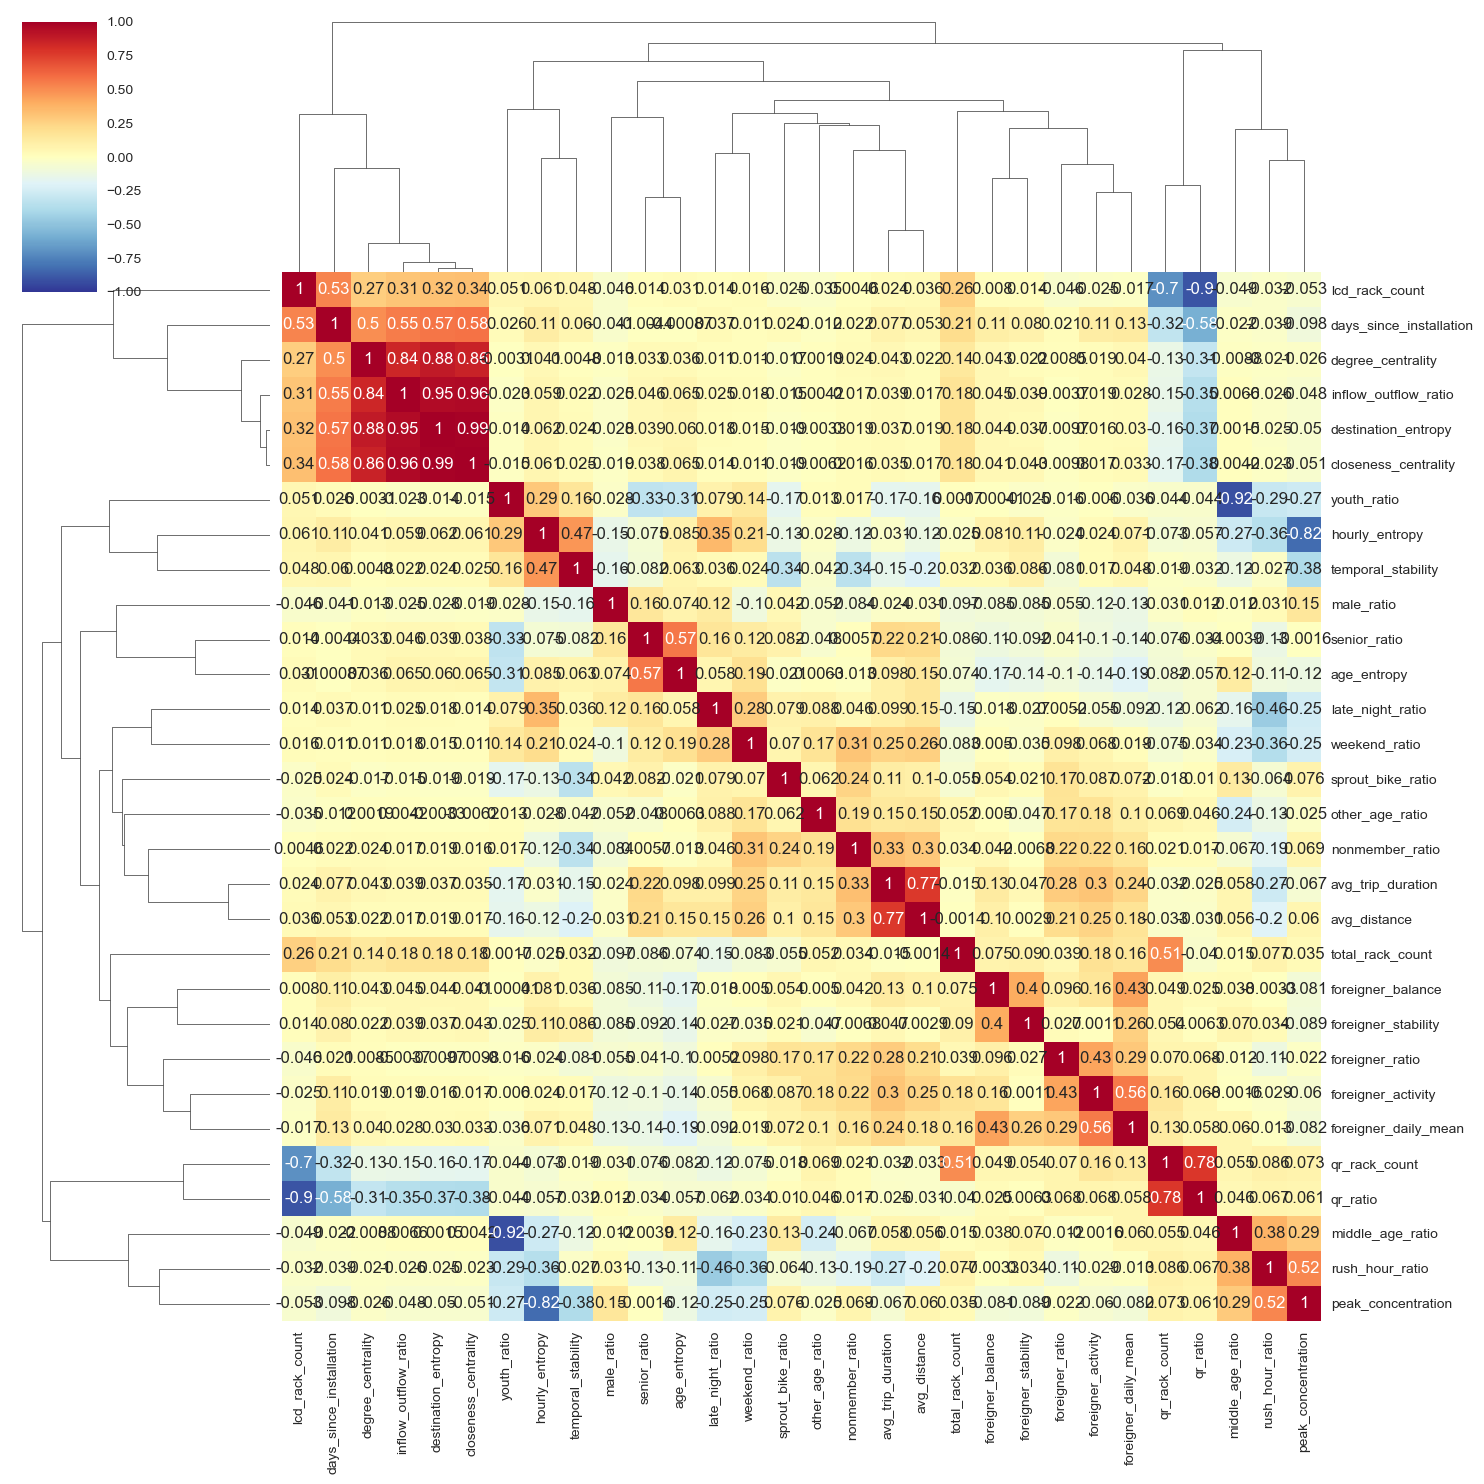

In [13]:
#correlation matrix
cor = station_st.select_dtypes(include='number').corr()

sns.clustermap(
    cor,
    annot=True,
    cmap='RdYlBu_r',
    vmin=-1,
    vmax=1,
    figsize=(15,15)
)

plt.show()

In [14]:
station_st[
    station_st[
        ['rush_hour_ratio',
         'late_night_ratio',
         'hourly_entropy',
         'peak_concentration',
         'temporal_stability',
         'weekend_ratio']
    ].isnull().all(axis=1)
]
#There is no record that people use this renatl station in novembe 2024. So, The null value came.

,lcd_rack_count,qr_rack_count,total_rack_count,qr_ratio,avg_trip_duration,avg_distance,sprout_bike_ratio,foreigner_ratio,nonmember_ratio,rush_hour_ratio,...,age_entropy,destination_entropy,inflow_outflow_ratio,degree_centrality,closeness_centrality,foreigner_activity,foreigner_balance,foreigner_stability,foreigner_daily_mean,days_since_installation
95,-0.725532,-0.302536,-1.282593,0.802099,NaN,NaN,NaN,NaN,NaN,NaN,...,1.497817,-1.037079,-1.007519,-0.858814,-1.049441,-0.346072,-0.782958,-0.955809,-1.319987,-0.781839
211,0.775232,-0.973492,-0.377949,-1.249085,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.727224,-1.037079,-1.007519,-0.858814,-1.049441,-0.116878,-0.491679,0.524139,0.431726,0.628171
391,-0.725532,1.039374,0.526695,0.802099,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.399448,-1.037079,-1.007519,-0.858814,-1.049441,-0.346072,-0.782958,-0.955809,-1.319987,1.628064
910,-0.725532,0.368419,-0.377949,0.802099,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.437496,1.023001,1.004709,0.603034,0.744194,-0.346072,-0.782958,-0.955809,-1.319987,-0.488190
1316,3.776761,-0.973492,3.240627,-1.249085,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.939033,0.560898,0.603034,0.917533,-0.346072,-0.782958,-0.955809,-1.319987,0.246551
1337,-0.725532,3.052241,3.240627,0.802099,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.533395,1.078611,-0.004700,1.057327,-0.346072,-0.782958,-0.955809,-1.319987,-0.375439
1354,-0.725532,0.100037,-0.739806,0.802099,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.112056,-1.037079,-1.007519,-0.858814,-1.049441,-0.346072,-0.782958,-0.955809,-1.319987,-0.849986
1396,0.775232,-0.973492,-0.377949,-1.249085,NaN,NaN,NaN,NaN,NaN,NaN,...,0.507050,0.898554,0.386101,0.389506,0.937224,-0.254394,0.382158,0.976816,-0.058753,0.857390
1508,-0.725532,0.368419,-0.377949,0.802099,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-1.037079,-1.007519,-0.858814,-1.049441,-0.346072,-0.782958,-0.955809,-1.319987,-0.695108
1758,1.225461,-0.973492,0.164838,-1.249085,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.137018,1.562315,1.728165,1.172658,-0.346072,-0.782958,-0.955809,-1.319987,1.652844


In [15]:
mask = station_st[
    ['rush_hour_ratio',
     'late_night_ratio',
     'hourly_entropy',
     'peak_concentration',
     'temporal_stability',
     'weekend_ratio']
].isnull().all(axis=1)

print(mask.sum())

36


In [19]:
station_st = station_st.fillna(0)
#I made its value to 0

In [21]:
pca = PCA(random_state = 2000, n_components = None)
pca.fit_transform(station_st)

array([[-2.13974272e+00,  2.08933573e+00,  1.59614237e+00, ...,
        -1.53714766e-02,  1.83770393e-16,  9.10372875e-16],
       [ 1.83809052e+00,  3.85134664e-01,  3.36105606e+00, ...,
        -7.17723921e-02,  2.92240311e-16,  1.16754110e-15],
       [ 1.30527000e+00,  2.37289485e+00,  1.17499543e+00, ...,
        -7.83580901e-02, -5.90771092e-16,  3.23050356e-15],
       ...,
       [-3.00549380e+00, -3.83409267e-01, -1.13402189e+00, ...,
         1.83189256e-02,  6.57059930e-16, -1.15533972e-15],
       [-3.56692080e+00,  2.47176238e+00, -1.50362239e+00, ...,
        -8.22945152e-03, -1.51908001e-15,  1.98139880e-16],
       [-3.37701556e+00,  1.65763544e+00,  4.25442487e-01, ...,
        -8.79940798e-03,  6.51429978e-16, -2.61859944e-16]])

In [23]:

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(1, pca.n_components_ + 1)],
    index=station_st.columns
)

loadings_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
lcd_rack_count,0.290925,0.019015,-0.080133,0.117283,-0.415011,0.079356,0.212268,0.152875,0.159547,0.085446,...,-0.018327,-0.004246,0.024759,0.004740,0.029946,0.442364,-0.004514,0.001231,2.094916e-11,5.833305e-01
qr_rack_count,-0.199750,0.024241,0.141648,-0.302383,0.424259,-0.085341,0.117268,0.197101,0.162764,0.081243,...,0.005070,-0.023246,-0.007467,0.012566,-0.031858,-0.341853,0.002804,-0.000577,2.342902e-11,6.523843e-01
total_rack_count,0.081411,0.055607,0.094377,-0.266307,0.071697,-0.019394,0.414017,0.450052,0.411800,0.212551,...,-0.015259,-0.036460,0.019782,0.022657,-0.006852,0.072387,-0.001661,0.000705,-1.737687e-11,-4.838597e-01
qr_ratio,-0.308263,-0.018783,0.100996,-0.174884,0.404550,-0.070444,-0.106812,-0.046700,-0.069404,-0.052517,...,-0.012556,-0.013983,0.018858,-0.018960,0.059518,0.811002,-0.016017,0.010531,9.397599e-17,9.147329e-15
avg_trip_duration,0.048946,-0.162579,0.383009,0.161363,-0.011246,0.086824,0.071209,0.117160,-0.277607,-0.093935,...,-0.177251,-0.022892,0.040032,0.678579,-0.044544,0.005893,-0.010842,0.000541,-9.747476e-17,1.035821e-17
avg_distance,0.036544,-0.122403,0.372160,0.197602,-0.018590,0.042796,0.097739,0.185466,-0.282510,-0.142054,...,0.232726,-0.093345,-0.052231,-0.630021,0.030845,-0.015491,0.013513,0.000053,-4.695266e-17,-1.143584e-16
sprout_bike_ratio,-0.009875,0.016587,0.211022,0.106927,-0.068042,-0.082969,-0.340296,-0.166284,0.496560,0.188241,...,0.092399,-0.012996,0.006313,0.010398,-0.000201,-0.002496,-0.001197,0.000353,-1.181413e-16,-2.587601e-16
foreigner_ratio,0.001434,-0.122304,0.281631,-0.084596,-0.078622,-0.049823,0.061670,-0.345100,-0.049032,0.251152,...,0.027798,-0.160890,-0.018550,-0.027196,-0.008074,-0.012144,-0.004675,-0.001243,8.874502e-17,-1.806801e-16
nonmember_ratio,0.017946,-0.116134,0.302663,0.076182,-0.075829,-0.238984,-0.039448,0.012890,0.254311,-0.244874,...,-0.058136,0.005820,-0.009600,-0.079909,-0.032008,-0.021669,0.005403,0.000598,1.425974e-17,-1.942550e-16
rush_hour_ratio,-0.065295,0.392319,-0.015986,-0.147255,-0.091925,0.063429,0.104860,-0.056295,-0.109612,-0.076032,...,-0.125208,-0.180851,-0.020450,0.079690,-0.260752,-0.017200,0.000708,0.000773,-4.265313e-16,1.028609e-16


In [25]:
pc_names = {
    'PC1': 'Network Centrality',
    'PC2': 'Commuter Demand',
    'PC3': 'Tourist Hub',
    'PC4': 'Senior HUb',
    'PC5': 'QR Rack',
    'PC6': 'Age Composition',
    'PC7': 'Station Capacity',
    'PC8': 'Foreigner Stability',
    'PC9': 'Sprout Bike Usage',
    'PC10': 'Gender Pattern',
    'PC11': 'Age Composition',
    'PC12': 'Late-night Activity'
}

In [27]:
pc_summary = pd.DataFrame({
    'PC': [
        'PC1','PC2','PC3','PC4',
        'PC5','PC6','PC7','PC8',
        'PC9','PC10','PC11','PC12'
    ],
    'Interpretation': [
        'Network Centrality',
        'Commuter Demand',
        'Tourist Hub',
        'Senior HUb',
        'QR Rack',
        'Age Composition',
        'Station Capacity',
        'Foreigner Stability',
        'Sprout Bike Usage',
        'Gender Pattern',
        'Other Age Composition',
        'Late-night Activity'
    ]
})

pc_summary

,PC,Interpretation
0,PC1,Network Centrality
1,PC2,Commuter Demand
2,PC3,Tourist Mobility
3,PC4,Senior Usage
4,PC5,Rack Infrastructure
5,PC6,Age Composition
6,PC7,Station Capacity
7,PC8,Foreigner Stability
8,PC9,Sprout Bike Usage
9,PC10,Gender Pattern


In [29]:
from sklearn.decomposition import PCA

pca = PCA()

scores = pca.fit_transform(station_st)

In [31]:
pc_list = [
    f'PC{i}'
    for i in range(1, pca.n_components_ + 1)
]

In [33]:
scores_df = pd.DataFrame(
    scores,
    columns=pc_list,
    index=station_st.index
)

In [35]:
scores_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30
0,-2.139743,2.089336,1.596142,-1.216798,-0.257693,0.353619,0.010002,-0.311169,2.718197,2.097733,...,0.289712,-0.577534,0.299970,0.249917,0.494709,-0.044425,0.064864,-0.015371,1.837704e-16,9.103729e-16
1,1.838091,0.385135,3.361056,-3.085883,0.523941,0.314704,0.285459,-2.765572,0.039910,2.307551,...,0.176908,1.487067,0.383405,-0.048006,0.491625,0.229989,0.031462,-0.071772,2.922403e-16,1.167541e-15
2,1.305270,2.372895,1.174995,-0.852878,1.088878,1.013864,-1.071011,-1.617137,0.485462,0.756717,...,-0.624692,-0.385975,0.029167,-0.344490,-0.135801,0.432980,0.037318,-0.078358,-5.907711e-16,3.230504e-15
3,-1.738325,1.559542,1.600897,-0.638474,-0.132949,1.891559,-0.047480,0.309651,0.780586,1.558900,...,-0.353631,0.261288,0.262610,-0.091001,-0.007567,0.169482,0.090739,-0.015730,1.714804e-16,4.051655e-15
4,1.796276,1.580725,2.000518,-0.895618,1.244835,0.419140,-2.106914,-1.046226,0.464168,1.655756,...,0.071142,-0.119841,0.576691,-0.142367,0.314650,0.305264,0.071587,0.337582,2.263590e-15,9.070595e-15


In [37]:
pcs_12 = scores_df[
    [f'PC{i}' for i in range(1,13)]
]

In [39]:
pcs_12_named = pcs_12.rename(
    columns=pc_names
)

In [41]:
pcs_12_named.head()

,Network Centrality,Commuter Demand,Tourist Mobility,Senior Usage,Rack Infrastructure,Age Composition,Station Capacity,Foreigner Stability,Sprout Bike Usage,Gender Pattern,Other Age Composition,Late-night Activity
0,-2.139743,2.089336,1.596142,-1.216798,-0.257693,0.353619,0.010002,-0.311169,2.718197,2.097733,0.674596,-0.544151
1,1.838091,0.385135,3.361056,-3.085883,0.523941,0.314704,0.285459,-2.765572,0.039910,2.307551,1.298961,-1.249156
2,1.305270,2.372895,1.174995,-0.852878,1.088878,1.013864,-1.071011,-1.617137,0.485462,0.756717,0.941482,-0.732080
3,-1.738325,1.559542,1.600897,-0.638474,-0.132949,1.891559,-0.047480,0.309651,0.780586,1.558900,-0.821690,-0.354849
4,1.796276,1.580725,2.000518,-0.895618,1.244835,0.419140,-2.106914,-1.046226,0.464168,1.655756,-0.074362,-0.543253


In [43]:
clusters = pcs_12_named.copy()

In [45]:
clusters

,Network Centrality,Commuter Demand,Tourist Mobility,Senior Usage,Rack Infrastructure,Age Composition,Station Capacity,Foreigner Stability,Sprout Bike Usage,Gender Pattern,Other Age Composition,Late-night Activity
0,-2.139743,2.089336,1.596142,-1.216798,-0.257693,0.353619,0.010002,-0.311169,2.718197,2.097733,0.674596,-0.544151
1,1.838091,0.385135,3.361056,-3.085883,0.523941,0.314704,0.285459,-2.765572,0.039910,2.307551,1.298961,-1.249156
2,1.305270,2.372895,1.174995,-0.852878,1.088878,1.013864,-1.071011,-1.617137,0.485462,0.756717,0.941482,-0.732080
3,-1.738325,1.559542,1.600897,-0.638474,-0.132949,1.891559,-0.047480,0.309651,0.780586,1.558900,-0.821690,-0.354849
4,1.796276,1.580725,2.000518,-0.895618,1.244835,0.419140,-2.106914,-1.046226,0.464168,1.655756,-0.074362,-0.543253
...,...,...,...,...,...,...,...,...,...,...,...,...
2761,-3.754787,3.302729,-0.419802,-0.357503,-0.000929,-0.731283,0.524737,-0.632436,0.885223,-0.941989,-1.230255,0.469804
2762,-3.312962,1.746953,-0.825331,1.903423,0.575519,-0.114166,0.342527,-0.870845,-0.699165,-0.144303,0.801809,-0.345094
2763,-3.005494,-0.383409,-1.134022,1.163255,0.980138,0.065772,-0.502313,-1.474779,1.776743,0.200454,-0.036828,0.884997
2764,-3.566921,2.471762,-1.503622,0.855379,0.343244,-1.130671,-0.704766,-0.470042,0.554615,0.944676,-0.575130,-0.513512


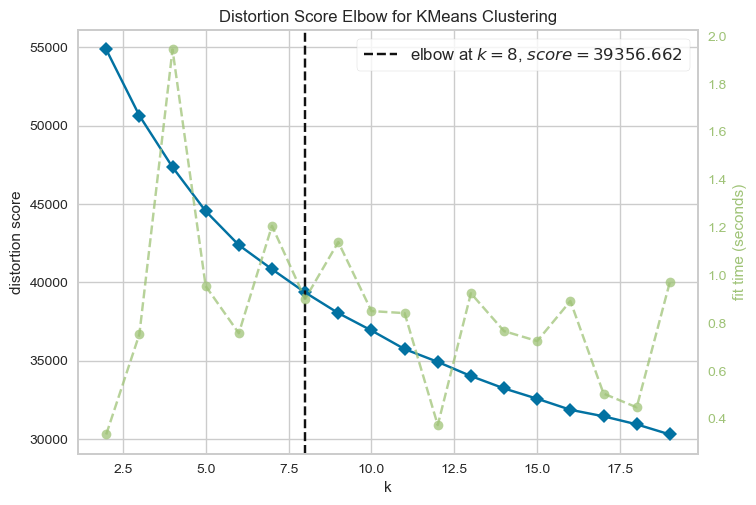

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [111]:
kmeans = KMeans(
    random_state=42,
    n_init=10
)

visualizer = KElbowVisualizer(
    kmeans,
    k=(2,20)
)

visualizer.fit(pcs_12)
visualizer.show()

In [ ]:
#elbow point is 8

In [101]:
optimal_k = 8

In [113]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,21):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(pcs_12)

    scores.append(
        silhouette_score(
            scores_df,
            labels
        )
    )

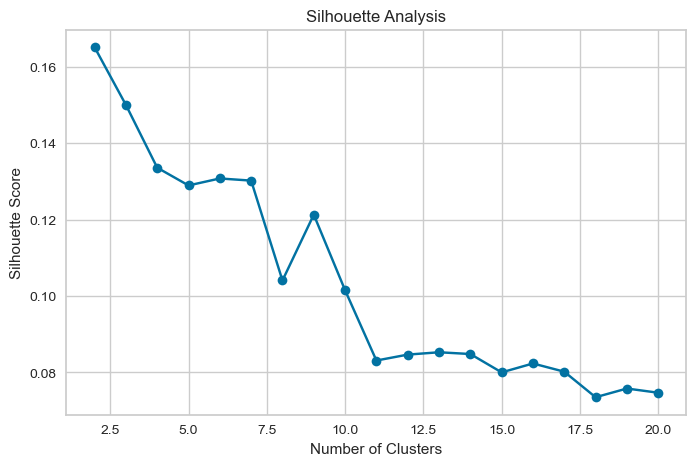

In [115]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,21),
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [117]:
for k in [6,7,8,9]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(pcs_12)

    print("\n===== K =", k, "=====")

    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


===== K = 6 =====
0    245
1    204
2    888
3    532
4    137
5    760
Name: count, dtype: int64

===== K = 7 =====
0     90
1    238
2    883
3    515
4    754
5    206
6     80
Name: count, dtype: int64

===== K = 8 =====
0    507
1    529
2     77
3    184
4    391
5    749
6    244
7     85
Name: count, dtype: int64

===== K = 9 =====
0    172
1    268
2    228
3    458
4    103
5    689
6     82
7     75
8    691
Name: count, dtype: int64


The elbow method suggested approximately eight clusters. However, the silhouette score showed only marginal improvement between six and seven clusters, while additional clusters resulted in several small groups containing less than 3% of all stations. Since the objective of this study was to identify interpretable station types rather than maximize segmentation, six clusters were selected as the final solution. This choice provided a balance between clustering quality, cluster size stability, and interpretability.

In [125]:
optimal_k = 6

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(pcs_12)

pcs_12["cluster"] = kmeans_labels

In [129]:
cluster_profile = (
    pcs_12
    .groupby("cluster")
    .mean()
)

cluster_profile

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
cluster,,,,,,,,,,,,
0,-0.260382,-0.640442,-0.625128,0.719332,-2.324634,0.645603,0.487858,0.480871,0.452934,0.423667,-0.090647,0.020484
1,-1.548974,3.700691,0.873776,-0.318732,-0.662043,-0.584794,-0.130995,0.158256,-0.441079,0.274740,-0.163703,0.300060
2,-2.416620,-0.629380,-0.380419,0.033093,0.164356,0.154700,-0.053752,-0.034608,0.009851,-0.087268,0.028658,-0.029871
3,0.954656,0.234620,0.220205,-1.060541,1.806296,-0.254260,-0.287536,0.005028,-0.053846,-0.083149,0.008395,-0.053439
4,0.276892,-1.792908,4.808315,0.318754,-0.300416,-0.990312,0.407661,-0.525743,-0.044560,-0.229130,-0.061542,-0.167095
5,2.605172,0.107457,-0.609434,0.499917,-0.475195,0.124593,0.068485,-0.065808,0.006598,-0.008850,0.044896,0.015284


In [149]:
pcs_12_named["cluster"] = kmeans_labels

In [151]:
pcs_12_named["cluster"].value_counts().sort_index()

cluster
0    245
1    204
2    888
3    532
4    137
5    760
Name: count, dtype: int64

In [153]:
pcs_12_named["cluster"] = kmeans_labels

cluster_profile_pca = (
    pcs_12_named
    .groupby("cluster")
    .mean()
)

cluster_profile_pca

,Network Centrality,Commuter Demand,Tourist Mobility,Senior Usage,Rack Infrastructure,Age Composition,Station Capacity,Foreigner Stability,Sprout Bike Usage,Gender Pattern,Other Age Composition,Late-night Activity
cluster,,,,,,,,,,,,
0,-0.260382,-0.640442,-0.625128,0.719332,-2.324634,0.645603,0.487858,0.480871,0.452934,0.423667,-0.090647,0.020484
1,-1.548974,3.700691,0.873776,-0.318732,-0.662043,-0.584794,-0.130995,0.158256,-0.441079,0.274740,-0.163703,0.300060
2,-2.416620,-0.629380,-0.380419,0.033093,0.164356,0.154700,-0.053752,-0.034608,0.009851,-0.087268,0.028658,-0.029871
3,0.954656,0.234620,0.220205,-1.060541,1.806296,-0.254260,-0.287536,0.005028,-0.053846,-0.083149,0.008395,-0.053439
4,0.276892,-1.792908,4.808315,0.318754,-0.300416,-0.990312,0.407661,-0.525743,-0.044560,-0.229130,-0.061542,-0.167095
5,2.605172,0.107457,-0.609434,0.499917,-0.475195,0.124593,0.068485,-0.065808,0.006598,-0.008850,0.044896,0.015284


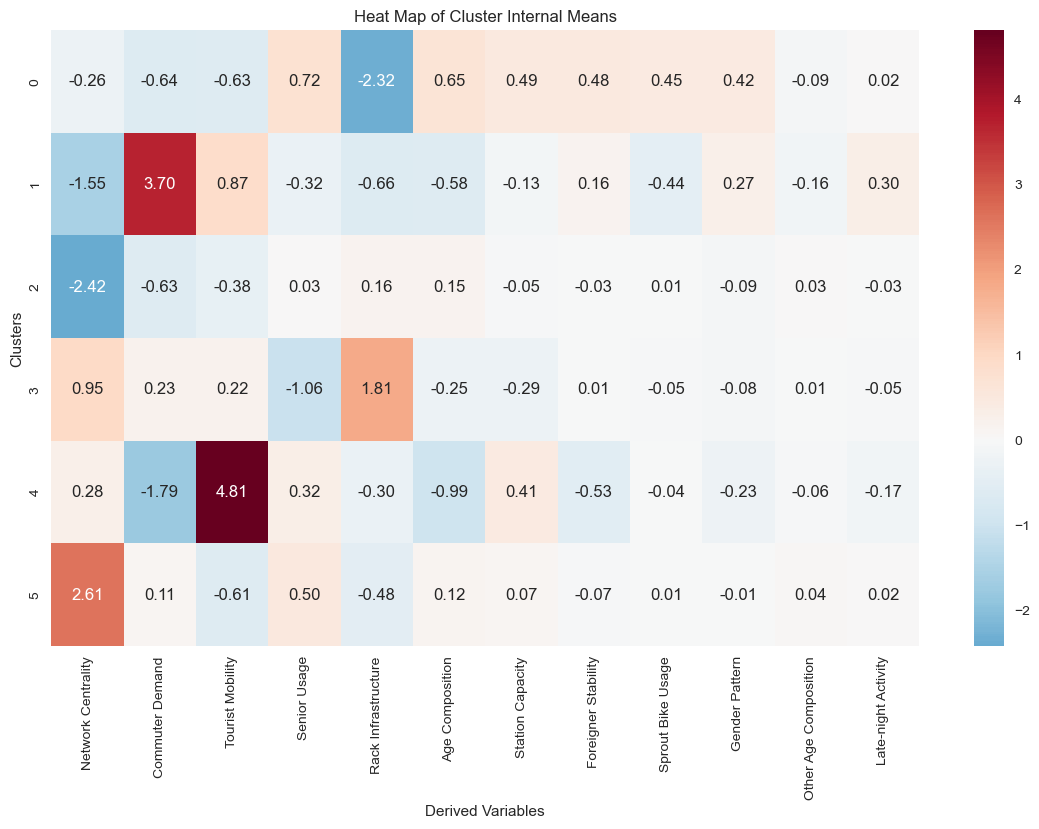

In [155]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_profile_pca,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Heat Map of Cluster Internal Means"
)

plt.xlabel("Derived Variables")
plt.ylabel("Clusters")

plt.show()

In [157]:
for c in cluster_profile_pca.index:

    print(f"\n===== Cluster {c} =====")

    print(
        cluster_profile_pca.loc[c]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )


===== Cluster 0 =====
Rack Infrastructure    2.324634
Senior Usage           0.719332
Age Composition        0.645603
Commuter Demand        0.640442
Tourist Mobility       0.625128
Name: 0, dtype: float64

===== Cluster 1 =====
Commuter Demand        3.700691
Network Centrality     1.548974
Tourist Mobility       0.873776
Rack Infrastructure    0.662043
Age Composition        0.584794
Name: 1, dtype: float64

===== Cluster 2 =====
Network Centrality     2.416620
Commuter Demand        0.629380
Tourist Mobility       0.380419
Rack Infrastructure    0.164356
Age Composition        0.154700
Name: 2, dtype: float64

===== Cluster 3 =====
Rack Infrastructure    1.806296
Senior Usage           1.060541
Network Centrality     0.954656
Station Capacity       0.287536
Age Composition        0.254260
Name: 3, dtype: float64

===== Cluster 4 =====
Tourist Mobility       4.808315
Commuter Demand        1.792908
Age Composition        0.990312
Foreigner Stability    0.525743
Station Capacity     

In [141]:
global_mean = (
    station_st
    .drop(columns=["cluster"])
    .mean()
)

In [143]:
cluster_vs_global = (
    cluster_profile
    - global_mean
)

cluster_vs_global.round(3)

,lcd_rack_count,qr_rack_count,total_rack_count,qr_ratio,avg_trip_duration,avg_distance,sprout_bike_ratio,foreigner_ratio,nonmember_ratio,rush_hour_ratio,...,age_entropy,destination_entropy,inflow_outflow_ratio,degree_centrality,closeness_centrality,foreigner_activity,foreigner_balance,foreigner_stability,foreigner_daily_mean,days_since_installation
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.208,-0.964,0.157,-1.243,-0.010,0.020,0.068,-0.123,-0.052,-0.156,...,-0.111,-0.979,-0.987,-0.845,-0.969,-0.013,0.090,0.064,0.097,0.687
1,-0.303,0.383,0.152,0.340,-0.325,-0.106,0.078,-0.132,-0.201,1.571,...,-0.617,-0.286,-0.276,-0.261,-0.291,-0.083,-0.096,-0.136,-0.056,-0.357
2,-0.726,0.416,-0.314,0.802,-0.135,-0.157,-0.051,-0.096,-0.113,-0.078,...,-0.010,-1.037,-1.008,-0.859,-1.049,-0.120,-0.078,-0.029,-0.101,-0.933
3,-0.721,0.896,0.339,0.801,-0.111,-0.150,-0.074,-0.070,-0.090,-0.010,...,0.080,0.947,0.931,0.791,0.940,-0.008,0.145,0.130,0.104,0.294
4,-0.265,0.362,0.167,0.323,1.942,2.065,0.879,2.036,2.188,-0.718,...,-0.130,0.121,0.135,0.088,0.113,1.949,0.341,-0.126,1.118,0.095
5,1.092,-0.970,0.009,-1.246,-0.024,-0.062,-0.090,-0.131,-0.129,-0.144,...,0.180,0.920,0.894,0.776,0.938,-0.179,-0.075,-0.019,-0.173,0.742


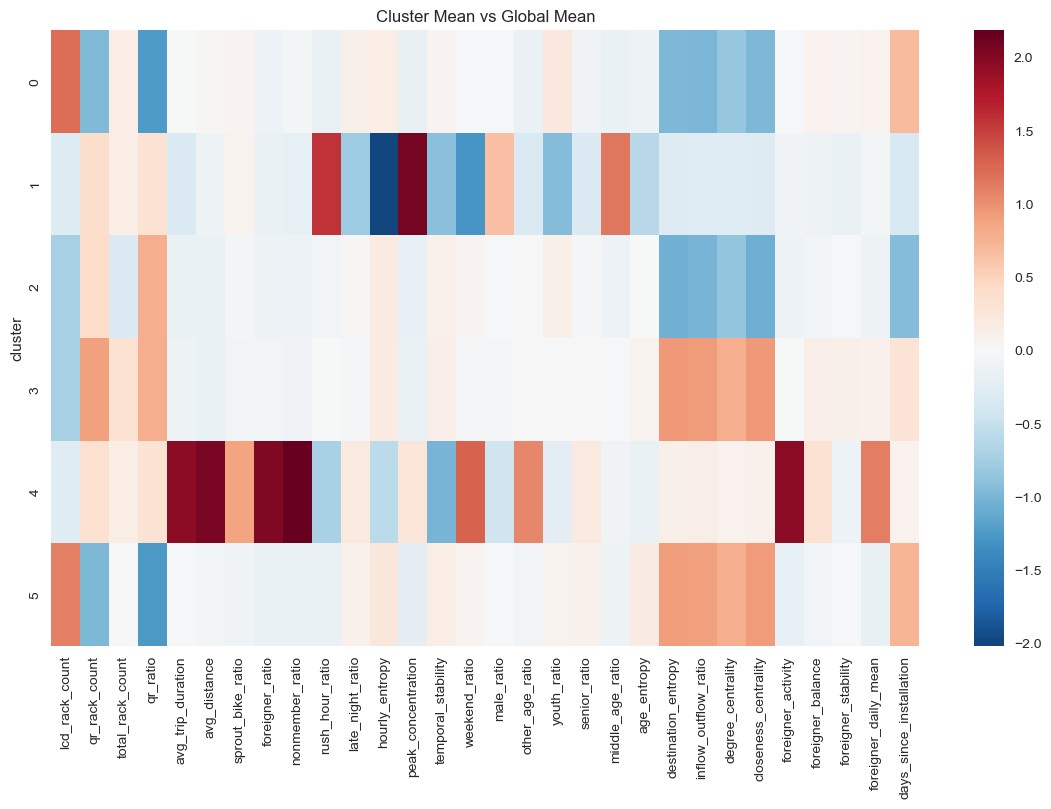

In [145]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_vs_global,
    cmap="RdBu_r",
    center=0
)

plt.title(
    "Cluster Mean vs Global Mean"
)

plt.show()

In [147]:
for c in cluster_vs_global.index:

    print(f"\n===== Cluster {c} =====")

    display(
        cluster_vs_global.loc[c]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )


===== Cluster 0 =====


qr_ratio                   1.243229
lcd_rack_count             1.207697
inflow_outflow_ratio       0.987396
destination_entropy        0.979472
closeness_centrality       0.968523
qr_rack_count              0.963633
degree_centrality          0.844634
days_since_installation    0.687163
youth_ratio                0.218257
peak_concentration         0.164922
Name: 0, dtype: float64


===== Cluster 1 =====


peak_concentration    2.078240
hourly_entropy        2.016822
rush_hour_ratio       1.570786
weekend_ratio         1.285432
middle_age_ratio      1.162389
youth_ratio           0.940405
temporal_stability    0.900524
late_night_ratio      0.790135
male_ratio            0.659778
age_entropy           0.617075
Name: 1, dtype: float64


===== Cluster 2 =====


...

destination_entropy        0.946527
closeness_centrality       0.939801
inflow_outflow_ratio       0.930656
qr_rack_count              0.896355
qr_ratio                   0.800965
degree_centrality          0.790844
lcd_rack_count             0.721301
total_rack_count           0.338964
days_since_installation    0.294410
hourly_entropy             0.189175
Name: 3, dtype: float64


===== Cluster 4 =====


nonmember_ratio         2.187956
avg_distance            2.065474
foreigner_ratio         2.035577
foreigner_activity      1.949210
avg_trip_duration       1.941761
weekend_ratio           1.290784
foreigner_daily_mean    1.118366
other_age_ratio         1.063854
temporal_stability      1.003905
sprout_bike_ratio       0.878508
Name: 4, dtype: float64


===== Cluster 5 =====


qr_ratio                   1.246460
lcd_rack_count             1.092367
qr_rack_count              0.970314
closeness_centrality       0.938171
destination_entropy        0.919951
inflow_outflow_ratio       0.893656
degree_centrality          0.776245
days_since_installation    0.741506
hourly_entropy             0.239013
peak_concentration         0.234694
Name: 5, dtype: float64

In [161]:
anova_results = []

features = pcs_12_named.columns.drop("cluster")

for feature in features:

    groups = [
        group[feature].values
        for _, group
        in pcs_12_named.groupby("cluster")
    ]

    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        "Feature": feature,
        "F Statistic": f_stat,
        "P Value": p_value
    })

anova_df = pd.DataFrame(anova_results)

In [163]:
anova_df.sort_values(
    "P Value"
)

,Feature,F Statistic,P Value
0,Network Centrality,2869.271095,0.000000e+00
2,Tourist Mobility,450.633432,0.000000e+00
4,Rack Infrastructure,843.993842,0.000000e+00
1,Commuter Demand,390.719152,1.745716e-317
3,Senior Usage,83.129345,1.553670e-81
5,Age Composition,44.044425,7.709147e-44
6,Station Capacity,21.056099,1.025003e-20
7,Foreigner Stability,19.282736,6.517628e-19
8,Sprout Bike Usage,17.699631,2.657104e-17
9,Gender Pattern,15.204499,9.147839e-15


In [165]:
significant_features = anova_df[
    anova_df["P Value"] < 0.05
]

significant_features.sort_values(
    "P Value"
)

,Feature,F Statistic,P Value
0,Network Centrality,2869.271095,0.000000e+00
2,Tourist Mobility,450.633432,0.000000e+00
4,Rack Infrastructure,843.993842,0.000000e+00
1,Commuter Demand,390.719152,1.745716e-317
3,Senior Usage,83.129345,1.553670e-81
5,Age Composition,44.044425,7.709147e-44
6,Station Capacity,21.056099,1.025003e-20
7,Foreigner Stability,19.282736,6.517628e-19
8,Sprout Bike Usage,17.699631,2.657104e-17
9,Gender Pattern,15.204499,9.147839e-15


In [167]:
print(
    "Significant Features:",
    len(significant_features)
)

print(
    "Total Features:",
    len(anova_df)
)

Significant Features: 12
Total Features: 12


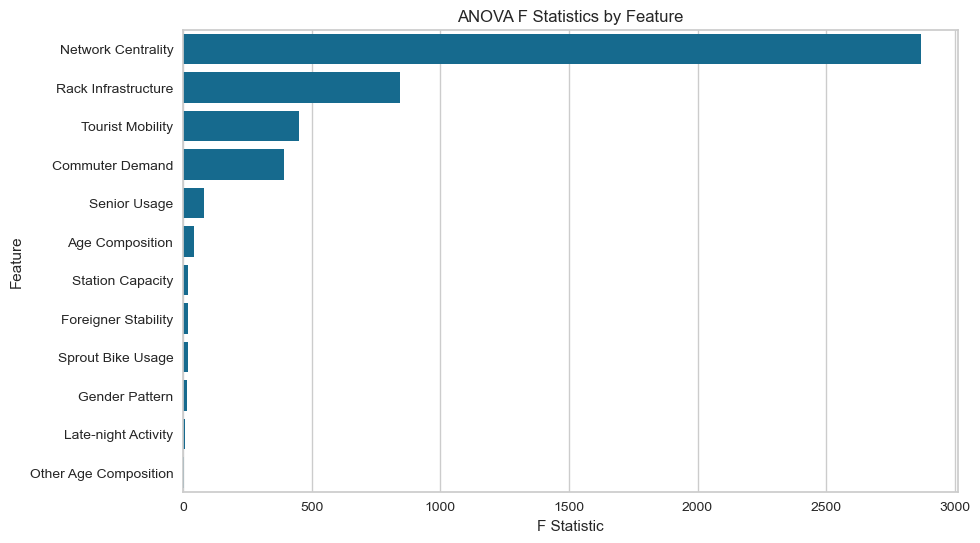

In [169]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=anova_df.sort_values(
        "F Statistic",
        ascending=False
    ),
    x="F Statistic",
    y="Feature"
)

plt.title(
    "ANOVA F Statistics by Feature"
)

plt.show()

In [171]:
X = pcs_12_named.drop(columns=["cluster"])

y = pcs_12_named["cluster"]

In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [175]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

In [177]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9693140794223827
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        49
           1       0.94      0.83      0.88        41
           2       0.98      0.99      0.99       178
           3       0.96      0.98      0.97       107
           4       0.89      0.89      0.89        27
           5       0.97      0.99      0.98       152

    accuracy                           0.97       554
   macro avg       0.96      0.94      0.95       554
weighted avg       0.97      0.97      0.97       554



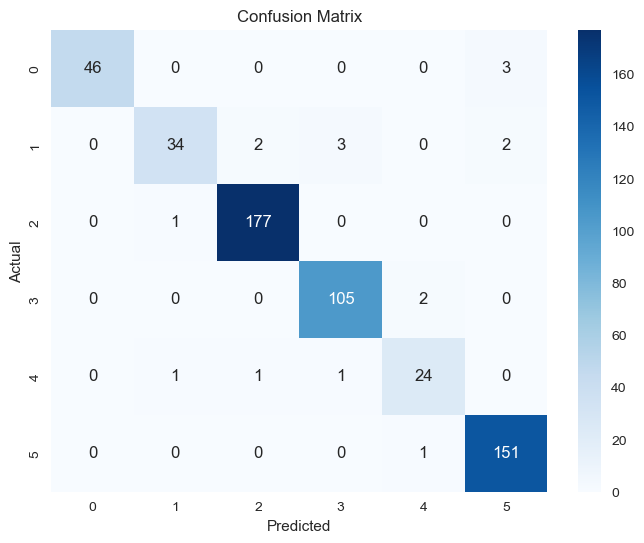

In [179]:
plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(
        y_test,
        y_pred
    ),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [181]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
0,Network Centrality,0.454442
4,Rack Infrastructure,0.215166
1,Commuter Demand,0.095365
2,Tourist Mobility,0.073737
3,Senior Usage,0.051497
8,Sprout Bike Usage,0.019842
7,Foreigner Stability,0.017666
6,Station Capacity,0.017541
9,Gender Pattern,0.017355
5,Age Composition,0.017326


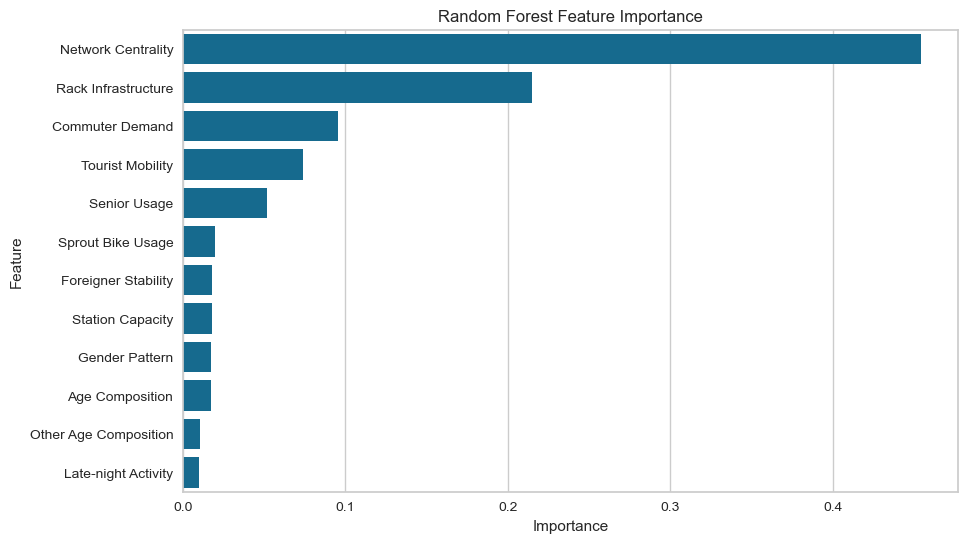

In [183]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [185]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

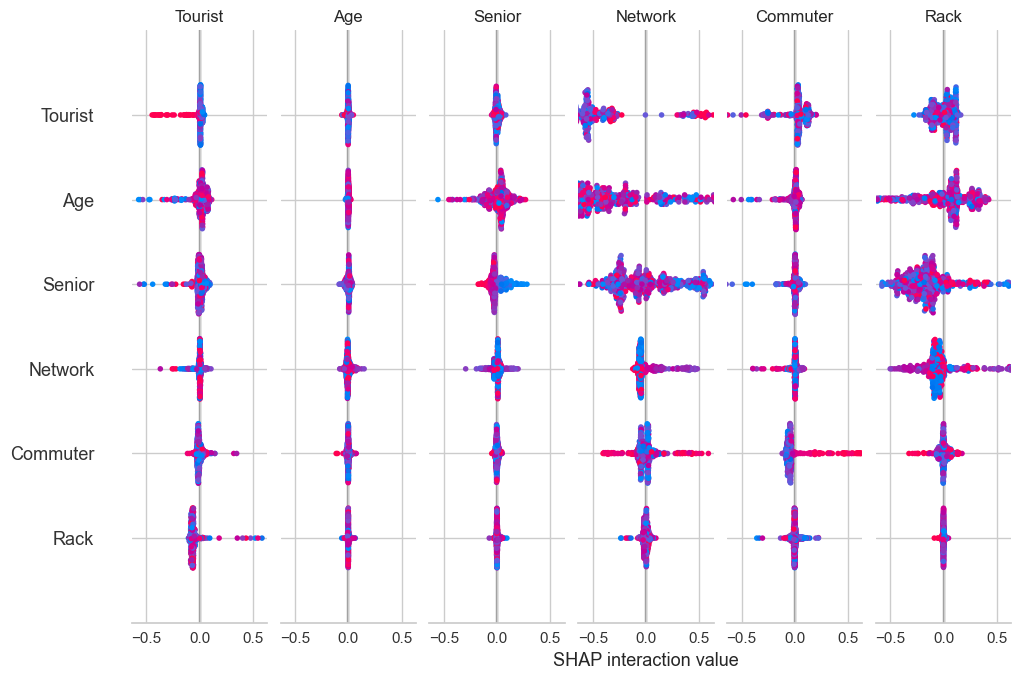

In [191]:
X_test_short = X_test.rename(columns={
    "Network Centrality":"Network",
    "Commuter Demand":"Commuter",
    "Tourist Mobility":"Tourist",
    "Senior Usage":"Senior",
    "Rack Infrastructure":"Rack",
    "Age Composition":"Age"
})

shap.summary_plot(
    shap_values,
    X_test_short
)

In [197]:
print(shap_values.shape)

(554, 12, 6)


In [195]:
len(shap_values)

554

In [203]:
import matplotlib.pyplot as plt
import shap

for i in range(6):

    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        max_display=6,
        show=False
    )

    plt.title(f"Cluster {i}")

    plt.savefig(
        f"cluster_{i}_shap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

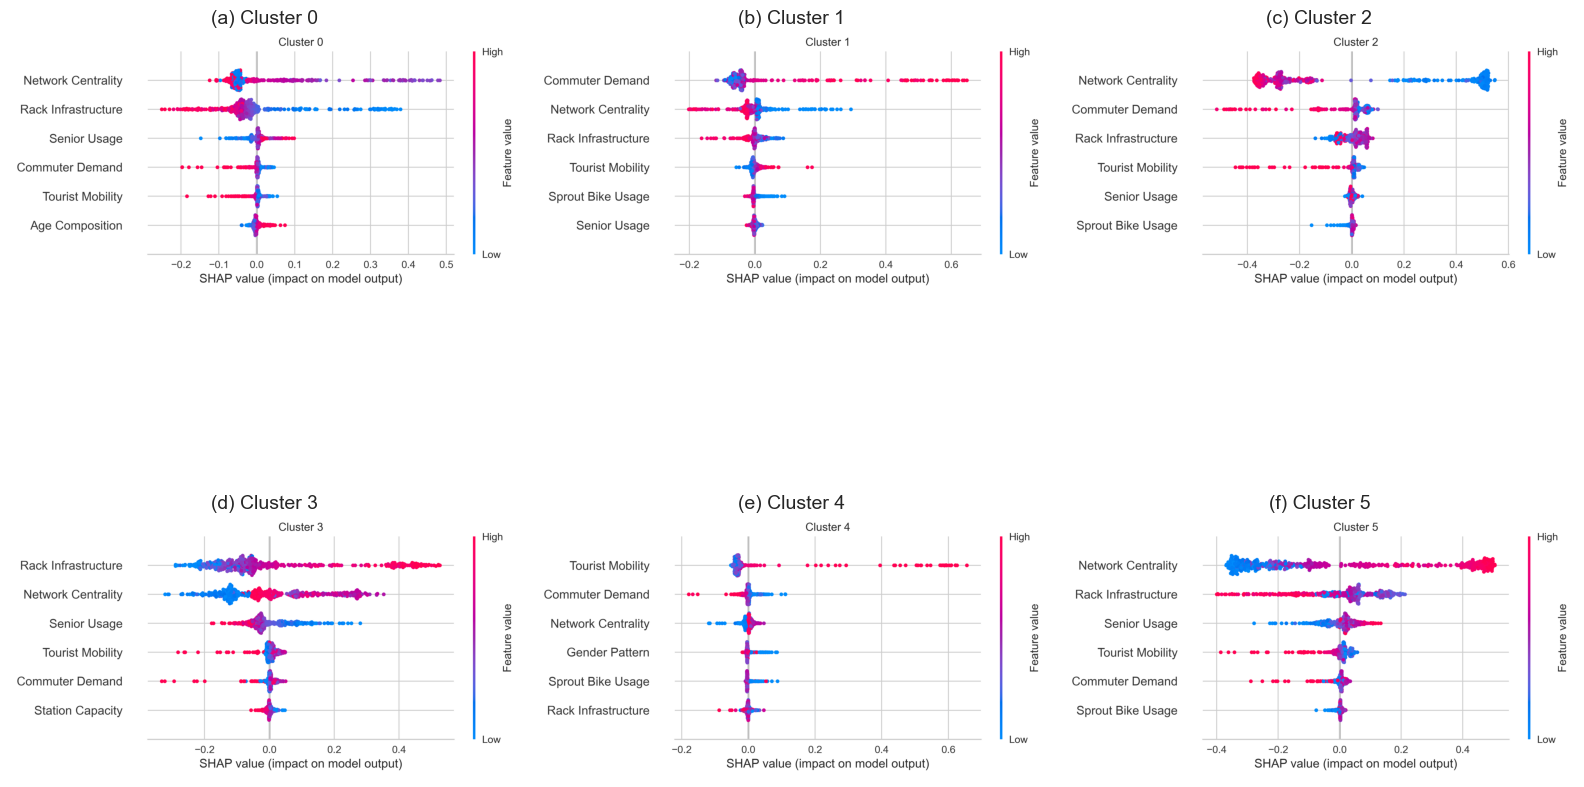

In [205]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 12)
)

for i, ax in enumerate(axes.flatten()):

    img = Image.open(f"cluster_{i}_shap.png")

    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"({chr(97+i)}) Cluster {i}",
        fontsize=14
    )

plt.tight_layout()

plt.savefig(
    "Figure10_SHAP_All_Clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

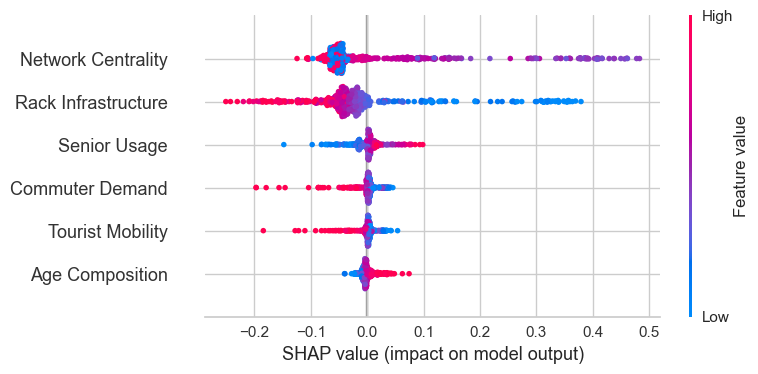

In [201]:
shap.summary_plot(
    shap_values[:, :, 0],
    X_test,
    max_display=6
)

In [91]:
X = station_st.copy()

y = cluster_labels

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [95]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

In [96]:
from sklearn.metrics import classification_report

pred = rf.predict(X_test)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       153
           1       0.80      0.60      0.69        20
           2       1.00      0.66      0.79        29
           3       0.86      0.60      0.70        42
           4       0.86      0.88      0.87        76
           5       0.94      0.98      0.96        46
           6       0.79      0.97      0.87        78
           7       0.84      0.77      0.81        35
           8       0.67      0.18      0.29        11
           9       0.85      0.89      0.87        64

    accuracy                           0.86       554
   macro avg       0.85      0.75      0.78       554
weighted avg       0.86      0.86      0.85       554



In [99]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_train)

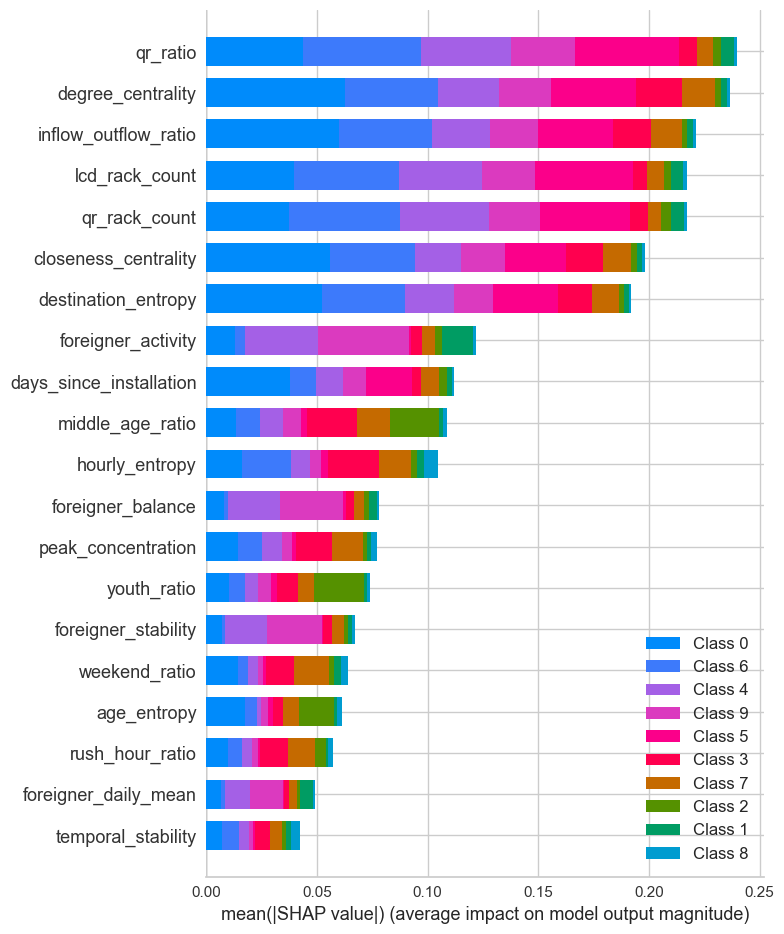

In [101]:
shap.summary_plot(
    shap_values,
    X_train,
    plot_type="bar"
)

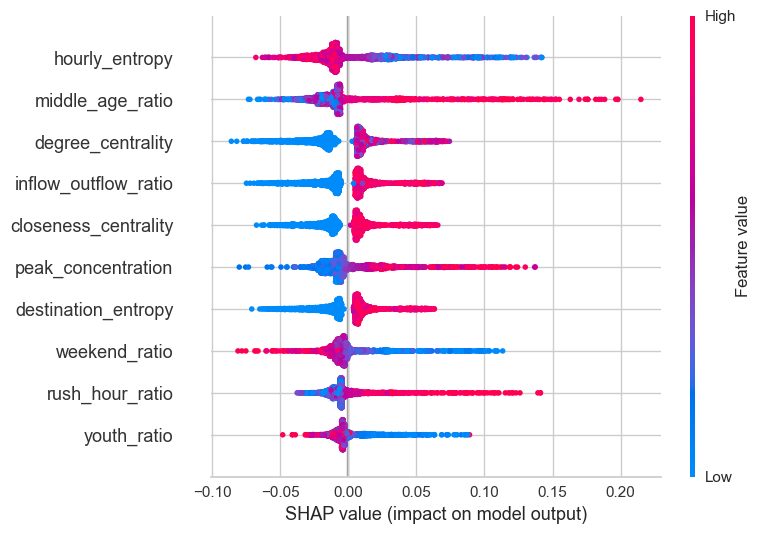

In [103]:
# local shap values
shap.summary_plot(
 shap_values[:, :, 3],
 X_train,
 max_display=10
)